<a href="https://colab.research.google.com/github/EngrTayab/House_Price_Predictor_Model/blob/main/MultiLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Student performance.zip')
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Spliting feature and target values
x=df.drop(['Performance Index'],axis=1).values
y=df['Performance Index'].values

#Split into trainning and testing data
X_train,X_test,Y_train,Y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
print(X_train.shape)
print(X_test.shape)

(8000, 5)
(2000, 5)


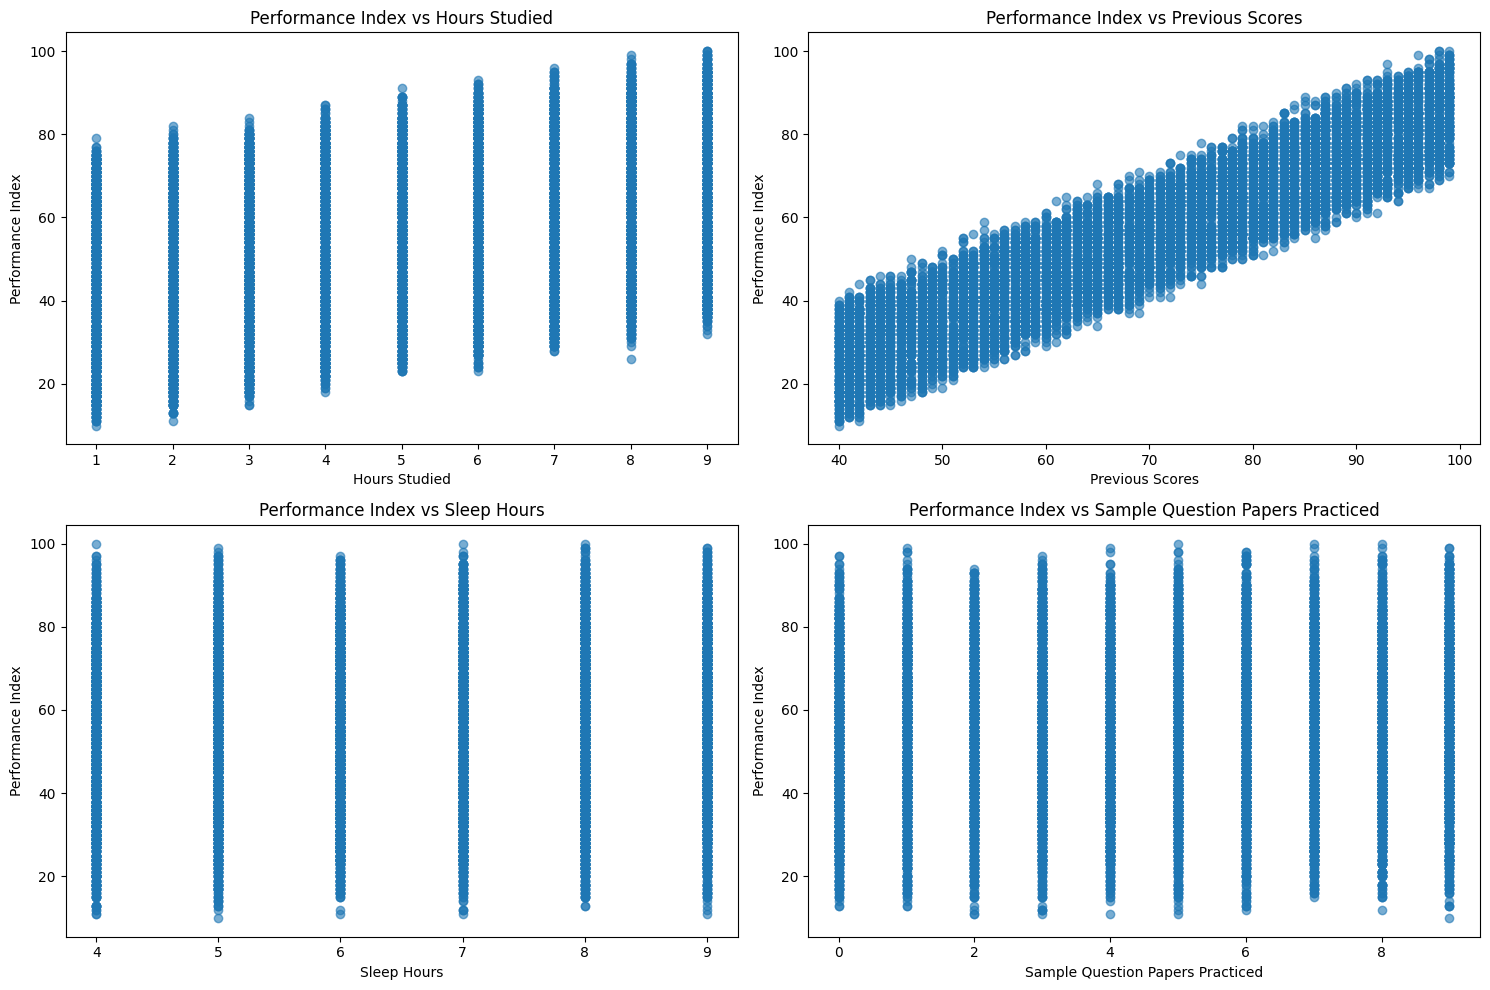

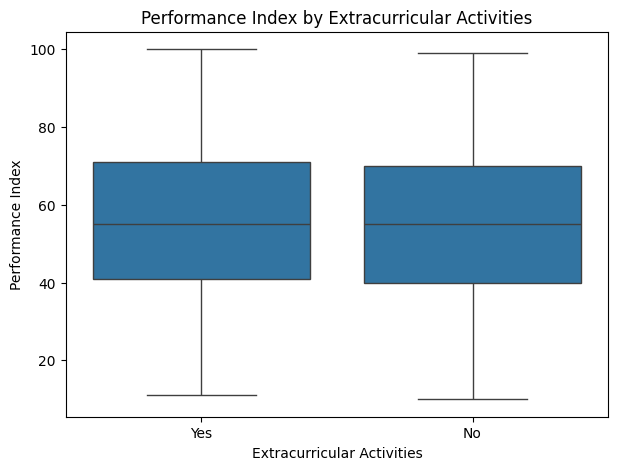

In [31]:
features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    plt.scatter(df[feature], df['Performance Index'], alpha=0.6)
    plt.title(f'Performance Index vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Performance Index')
plt.tight_layout()
plt.show()

# For 'Extracurricular Activities', which is categorical, a box plot might be more suitable.
plt.figure(figsize=(7, 5))
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df)
plt.title('Performance Index by Extracurricular Activities')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Performance Index')
plt.show()


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

model = LinearRegression()

# Create a copy to avoid modifying the original X_train directly
X_train_processed = X_train.copy()

# It contains Extracurricular Activities contain 'Yes' and 'No' strings. Convert these to numerical values (0 and 1).
le = LabelEncoder()
X_train_processed[:, 2] = le.fit_transform(X_train_processed[:, 2])

# Ensure all features are numerical (float type) as required by LinearRegression
X_train_processed = X_train_processed.astype(float)

model.fit(X_train_processed, Y_train)

LinearRegression()

In [ ]:
# Process X_test similarly to X_train
X_test_processed = X_test.copy()

# Use the same LabelEncoder 'le' that was fitted on X_train_processed
# to transform the 'Extracurricular Activities' column in X_test

X_test_processed[:, 2] = le.transform(X_test_processed[:, 2])

# Ensure all features are numerical (float type) as required by LinearRegression
X_test_processed = X_test_processed.astype(float)

ypred=model.predict(X_test_processed)
print(ypred)

[54.71185392 22.61551294 47.90314471 ... 16.79341955 63.34327368
 45.94262301]


In [ ]:
print(f'Accuracy of the model:{model.score(X_test_processed,Y_test) *100:.4f}%')

Accuracy of the model:98.8983%


In [ ]:

# The order of features should be: 'Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced'
# For 'Extracurricular Activities', input 'Yes' or 'No'
manual_inputs = np.array([[7, 85, 'Yes', 8, 3]]) # Example values

# Make a copy for processing
manual_inputs_processed = manual_inputs.copy()

# Apply the same LabelEncoder for 'Extracurricular Activities' (index 2)
manual_inputs_processed[:, 2] = le.transform(manual_inputs_processed[:, 2])

# Ensure all features are numerical (float type)
manual_inputs_processed = manual_inputs_processed.astype(float)

# Get prediction from the model
manual_prediction = model.predict(manual_inputs_processed)

print(f"Predicted Performance Index: {manual_prediction[0]:.2f}")

Predicted Performance Index: 77.49


In [34]:
feature_names = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
coefficients = model.coef_
intercept = model.intercept_

# Map numerical 'Extracurricular Activities' back to original 'Yes'/'No' for interpretation
# Or, more accurately, understand that the coefficient corresponds to the 'Yes' category when encoded as 1.

# Create a DataFrame for better visualization
coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

display(coeff_df.sort_values(by='Coefficient', ascending=False))


,Feature,Coefficient
0,Hours Studied,2.852484
1,Previous Scores,1.016988
2,Extracurricular Activities,0.608617
3,Sleep Hours,0.476941
4,Sample Question Papers Practiced,0.191831


In [36]:
# Check by coeffiecient and intercept
y=2.852484*7 + 1.016988*85 + 0.608617*1 + 0.476941*8 + 0.191831*3 + (-33.92)
print(y)

77.49100599999998
